In [1]:
# Chargement des dépendances pour l'entrainement et l'évaluation du modèle énergie.
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from energy_sights.config import PROCESSED_DATA_DIR
from energy_sights.modeling.train import ModelTrainer
from energy_sights.modeling.evaluate import evaluate_regression, print_metrics, plot_residuals, \
    plot_features_importance, print_feature_importances
from energy_sights.modeling.tuning import tune_model
from energy_sights.logging_config import setup_logging
from energy_sights.preprocessing import nan_percent, numeric_describe
from energy_sights.plots import interactive_distribution
from energy_sights.modeling import evaluate
from energy_sights.modeling import tuning
from importlib import reload

2026-02-18 22:56:13.143 | INFO     | energy_sights.config:<module>:11 - PROJ_ROOT path is: C:\ML_projects\energy_sights


2026-02-18 22:56:13 | INFO     | energy_sights.preprocessing - Starting the Preprocessing
2026-02-18 22:56:13.930 | INFO     | energy_sights.preprocessing:<module>:12 - Starting the Preprocessing
2026-02-18 22:56:13 | SUCCESS  | energy_sights.preprocessing - End of the preprocessing
2026-02-18 22:56:13.936 | SUCCESS  | energy_sights.preprocessing:<module>:91 - End of the preprocessing


In [2]:
reload(evaluate)
reload(tuning)

<module 'energy_sights.modeling.tuning' from 'C:\\ML_projects\\energy_sights\\energy_sights\\modeling\\tuning.py'>

In [2]:
setup_logging()

In [3]:
data_path: Path = PROCESSED_DATA_DIR / 'processed_data.csv'

In [4]:
df = pd.read_csv(filepath_or_buffer=data_path)

In [5]:
df.head()

,PrimaryPropertyType,PropertyGFATotal,Neighborhood,NumberofFloors,Latitude,Longitude,SiteEnergyUse(kBtu),TotalGHGEmissions,IsComplex,BuildingAge,AverageFloorArea,DistToCenter,ParkingRatio
0,Hotel,88434,Downtown,12,47.61220,-122.33799,7226362.5,249.98,0,89,7369.500000,11742.615082,0.000000
1,Hotel,103566,Downtown,11,47.61317,-122.33393,8387933.0,295.86,0,20,9415.090909,11743.170496,0.145453
2,Hotel,956110,Downtown,41,47.61393,-122.33810,72587024.0,2089.28,0,47,23319.756098,11742.794402,0.205748
3,Hotel,61320,Downtown,10,47.61412,-122.33664,6794584.0,286.43,0,90,6132.000000,11742.976556,0.000000
4,Hotel,175580,Downtown,18,47.61375,-122.34047,14172606.0,505.01,0,36,9754.444444,11742.512927,0.353115


In [6]:
# Contrôle de la qualité des donnees.
df.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 1491 entries, 0 to 1490
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   PrimaryPropertyType  1491 non-null   str    
 1   PropertyGFATotal     1491 non-null   int64  
 2   Neighborhood         1491 non-null   str    
 3   NumberofFloors       1491 non-null   int64  
 4   Latitude             1491 non-null   float64
 5   Longitude            1491 non-null   float64
 6   SiteEnergyUse(kBtu)  1491 non-null   float64
 7   TotalGHGEmissions    1491 non-null   float64
 8   IsComplex            1491 non-null   int64  
 9   BuildingAge          1491 non-null   int64  
 10  AverageFloorArea     1491 non-null   float64
 11  DistToCenter         1491 non-null   float64
 12  ParkingRatio         1491 non-null   float64
dtypes: float64(7), int64(4), str(2)
memory usage: 308.3 KB


In [7]:
df.columns.tolist()

['PrimaryPropertyType',
 'PropertyGFATotal',
 'Neighborhood',
 'NumberofFloors',
 'Latitude',
 'Longitude',
 'SiteEnergyUse(kBtu)',
 'TotalGHGEmissions',
 'IsComplex',
 'BuildingAge',
 'AverageFloorArea',
 'DistToCenter',
 'ParkingRatio']

In [8]:
# Verification des valeurs manquantes.
nan_percent(df=df)

PrimaryPropertyType ->  0.0000 %

PropertyGFATotal ->  0.0000 %

Neighborhood ->  0.0000 %

NumberofFloors ->  0.0000 %

Latitude ->  0.0000 %

Longitude ->  0.0000 %

SiteEnergyUse(kBtu) ->  0.0000 %

TotalGHGEmissions ->  0.0000 %

IsComplex ->  0.0000 %

BuildingAge ->  0.0000 %

AverageFloorArea ->  0.0000 %

DistToCenter ->  0.0000 %

ParkingRatio ->  0.0000 %



In [9]:
df.select_dtypes(include='string').nunique().rename('Count')

PrimaryPropertyType    16
Neighborhood           13
Name: Count, dtype: int64

In [10]:
# Analyse de la distribution de la cible afin de traiter les valeurs aberrantes.
q_98: float = df['SiteEnergyUse(kBtu)'].quantile(q=.98)

In [11]:
# Filtrage des observations au-dela du quantile retenu.
df_copy = df.copy()

In [12]:
final_df = df_copy[df_copy['SiteEnergyUse(kBtu)'] < q_98]

In [13]:
# Dimension du DataFrame final.
final_df.shape

(1461, 13)

In [14]:
# Analyse de la distribution de la cible.
interactive_distribution(df=final_df, col='SiteEnergyUse(kBtu)')

In [15]:
# Affichage des statistiques descriptives.
numeric_describe(df=final_df, col='SiteEnergyUse(kBtu)').head(n=10)

count     1.461000e+03
mean      6.028124e+06
std       8.716702e+06
min       5.713320e+04
25%       1.217509e+06
50%       2.603931e+06
75%       6.797647e+06
max       5.648520e+07
mode_1    5.713320e+04
mode_2    7.971180e+04
Name: SiteEnergyUse(kBtu), dtype: float64

In [16]:
# Definition des variables explicatives et de la cible pour la prediction de SiteEnergyUse(kBtu).
X = final_df.drop(columns=['SiteEnergyUse(kBtu)', 'TotalGHGEmissions'])
y = final_df.filter(items=['SiteEnergyUse(kBtu)'])

In [17]:
# Separation des donnees en ensembles d'entrainement et de test.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2)

In [18]:
X_train.head()

,PrimaryPropertyType,PropertyGFATotal,Neighborhood,NumberofFloors,Latitude,Longitude,IsComplex,BuildingAge,AverageFloorArea,DistToCenter,ParkingRatio
288,Small- and Mid-Sized Office,87178,Magnolia / Queen Anne,5,47.62224,-122.35850,0,46,17435.6,11741.462713,0.234188
562,Other,22800,Greater Duwamish,1,47.54134,-122.30529,1,22,22800.0,11738.381701,0.000000
164,Small- and Mid-Sized Office,89355,Downtown,6,47.60219,-122.33347,0,116,14892.5,11742.006101,0.000000
1097,Distribution Center,36040,Greater Duwamish,1,47.57258,-122.33059,0,62,36040.0,11739.046983,0.000000
1025,Distribution Center,21349,Greater Duwamish,1,47.58220,-122.32100,0,69,21349.0,11741.169982,0.000000


In [19]:
# Initialisation du modèle.
trainer_boost = ModelTrainer(model_type='xgboost')

In [20]:
# Construction du pipeline de modelisation.
base_model_boost = trainer_boost.build_pipeline(use_log_target=True)


2026-02-18 22:56:45 | INFO     | energy_sights.modeling.train - Model configuration with a logarithm transformation of the target .
2026-02-18 22:56:45.364 | INFO     | energy_sights.modeling.train:build_pipeline:85 - Model configuration with a logarithm transformation of the target .


In [21]:
# Optimisation des hyperparametres pour identifier le meilleur modèle.
best_model = tune_model(model=base_model_boost,
                        X_train=X_train,
                        y_train=y_train,
                        model_type='xgboost')

2026-02-18 22:56:45 | INFO     | energy_sights.modeling.tuning - Start of the tuning the: 2026-02-18 22:56:45.409359
2026-02-18 22:56:45.409 | INFO     | energy_sights.modeling.tuning:tune_model:49 - Start of the tuning the: 2026-02-18 22:56:45.409359
Fitting 5 folds for each of 20 candidates, totalling 100 fits
The best parameters finds are: {'regressor__model__subsample': 0.8, 'regressor__model__n_estimators': 300, 'regressor__model__min_child_weight': 3, 'regressor__model__max_depth': 4, 'regressor__model__learning_rate': 0.03, 'regressor__model__lambda': 2.0, 'regressor__model__gamma': 0.1, 'regressor__model__colsample_bytree': 0.7, 'regressor__model__alpha': 1.0}
The best Score (RMSE roughly): 1654.06


In [22]:
# Evaluation du modèle.
y_pred = best_model.predict(X_test)

In [23]:
y_pred

array([[1.20769575e+06],
       [1.74482662e+06],
       [9.54775812e+05],
       [1.54909938e+06],
       [8.84632800e+06],
       [1.69762512e+06],
       [2.56623600e+06],
       [1.05952588e+06],
       [1.82362362e+06],
       [2.67928550e+06],
       [1.31337275e+06],
       [1.18780600e+06],
       [1.04036338e+06],
       [1.68060012e+06],
       [9.10527000e+05],
       [1.11356070e+07],
       [1.52968425e+06],
       [2.10867275e+06],
       [1.21664562e+06],
       [8.98007250e+05],
       [1.02138720e+07],
       [1.75030812e+06],
       [1.64219812e+06],
       [6.50972300e+06],
       [1.69700525e+06],
       [1.19299975e+06],
       [1.64748230e+07],
       [1.44399512e+06],
       [2.24077975e+06],
       [2.45697450e+06],
       [2.75592225e+06],
       [1.91463825e+06],
       [1.08699100e+06],
       [9.86265125e+05],
       [5.86607200e+06],
       [1.22586175e+06],
       [1.06224238e+06],
       [1.35597112e+06],
       [4.05154375e+05],
       [1.84821600e+06],


In [24]:
y_pred.shape

(293, 1)

In [25]:
y_pred_train = best_model.predict(X_train)

In [26]:
y_pred_train[0:5]

array([[4.1871108e+06],
       [2.2483510e+06],
       [4.3347525e+06],
       [8.2736744e+05],
       [7.0818250e+05]], dtype=float32)

In [27]:
# Evaluation du modèle.
print_metrics(metrics=evaluate_regression(y_true=y_train, y_pred=y_pred_train, model_name='xgboost'))


 Model performance : xgboost
  RMSE (Root Mean Squared Error) : 4,450,956.15
  MAE  (Mean Absolute Error)     : 2,015,222.75
  MAPE (Error %)           : 42.60%
  R²   (Score explication)  : 0.7532


In [28]:
# Evaluation détaillée du modèle.
xgboost_metrics = evaluate_regression(y_test, y_pred, model_name='xgboost')

In [29]:
# Analyse complete des métriques de performance.
print_metrics(metrics=xgboost_metrics)


 Model performance : xgboost
  RMSE (Root Mean Squared Error) : 4,649,416.72
  MAE  (Mean Absolute Error)     : 2,194,380.00
  MAPE (Error %)           : 63.86%
  R²   (Score explication)  : 0.6277


In [30]:
type(y_test)

pandas.DataFrame

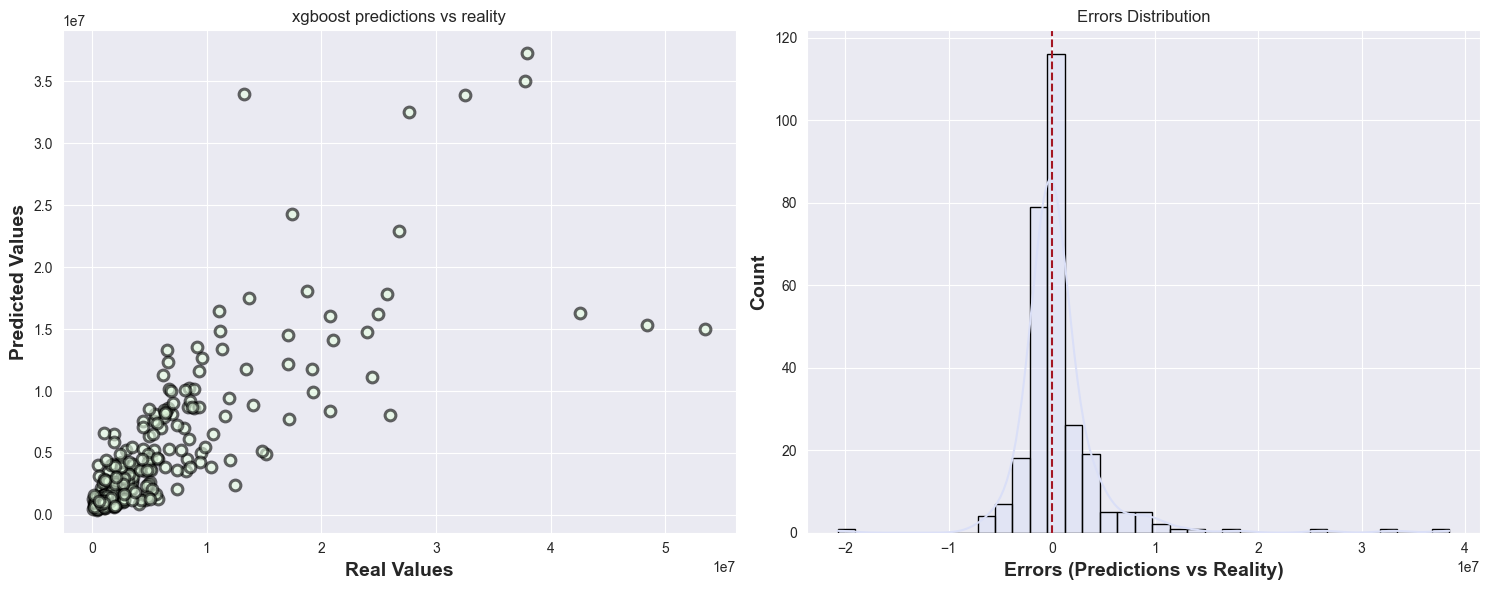

In [31]:
# Visualisation de la distribution des résidus.
plot_residuals(y_true=y_test, y_pred=y_pred, model_name='xgboost')

In [32]:
# Reprise de l'évaluation depuis une nouvelle configuration.
features_name: list[str] = X_train.columns.tolist()
importances = best_model.regressor_.named_steps['model'].feature_importances_

In [33]:
# Construction d'un tableau des importances pour faciliter l'interprétation du modèle.
fea_df = pd.DataFrame(data={
    'Features': features_name,
    'Importances': importances
})

In [34]:
fea_df = fea_df.sort_values(by='Importances', kind='quicksort', ascending=False)

In [35]:
fea_df

,Features,Importances
1,PropertyGFATotal,0.383448
0,PrimaryPropertyType,0.209963
3,NumberofFloors,0.099211
8,AverageFloorArea,0.061280
2,Neighborhood,0.055105
10,ParkingRatio,0.039370
6,IsComplex,0.036580
7,BuildingAge,0.033776
4,Latitude,0.028508
9,DistToCenter,0.026989


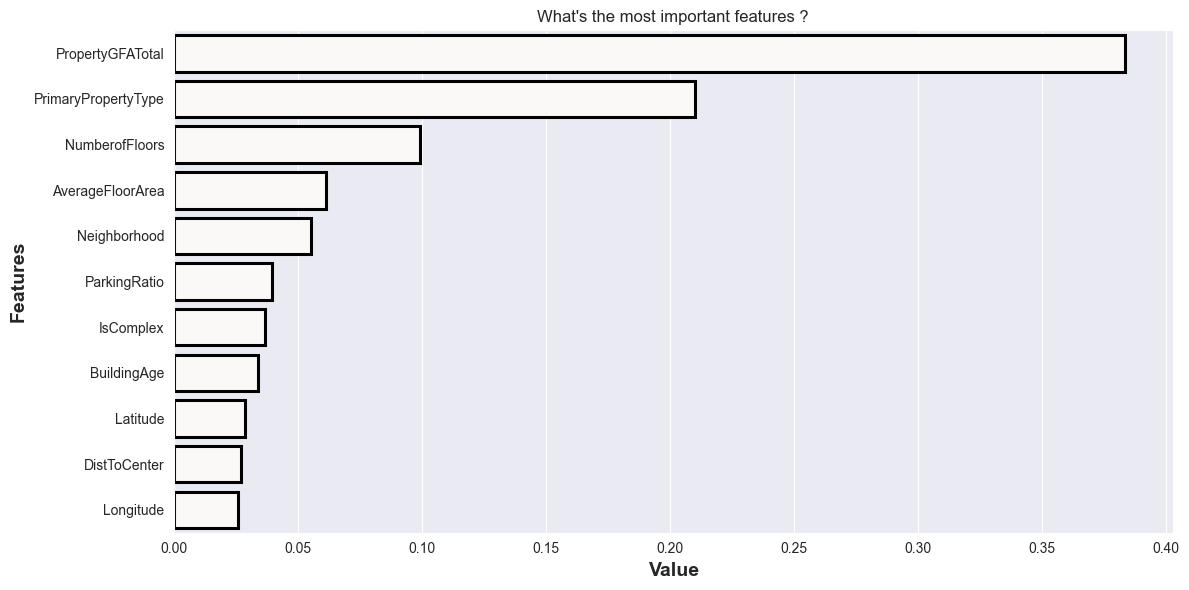

In [36]:
# Visualisation de l'importance des variables sur l'ensemble d'entrainement.
plot_features_importance(model=best_model, feature_names=X_train.columns.tolist())

### Improvement of the model with the removal of the useless features

In [37]:
# Suppression des colonnes peu contributives et reevaluation du modèle.
X_2 = X.drop(columns=['Latitude', 'ParkingRatio', 'Longitude', 'DistToCenter', 'IsComplex'])
y2 = y

In [38]:
# Separation des donnees.
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_2, y2, test_size=.2)

In [39]:
# Entrainement avec la meilleure configuration.
best_model_boost2 = tune_model(model=base_model_boost,
                               X_train=X_train2,
                               y_train=y_train2,
                               model_type='xgboost',
                               n_iter=30)

2026-02-18 22:57:36 | INFO     | energy_sights.modeling.tuning - Start of the tuning the: 2026-02-18 22:57:36.537754
2026-02-18 22:57:36.537 | INFO     | energy_sights.modeling.tuning:tune_model:49 - Start of the tuning the: 2026-02-18 22:57:36.537754
Fitting 5 folds for each of 30 candidates, totalling 150 fits
The best parameters finds are: {'regressor__model__subsample': 0.7, 'regressor__model__n_estimators': 300, 'regressor__model__min_child_weight': 5, 'regressor__model__max_depth': 8, 'regressor__model__learning_rate': 0.03, 'regressor__model__lambda': 1, 'regressor__model__gamma': 0.5, 'regressor__model__colsample_bytree': 0.7, 'regressor__model__alpha': 0.5}
The best Score (RMSE roughly): 1664.75


In [40]:
# Evaluation de la performance du modèle.
y_pred_train2 = best_model_boost2.predict(X_train2)

In [41]:
metrics_train2 = evaluate_regression(y_true=y_train2,
                                     y_pred=y_pred_train2,
                                     model_name='xgboost')

In [42]:
print_metrics(metrics=metrics_train2)


 Model performance : xgboost
  RMSE (Root Mean Squared Error) : 4,739,784.19
  MAE  (Mean Absolute Error)     : 2,109,363.25
  MAPE (Error %)           : 40.33%
  R²   (Score explication)  : 0.7250


In [43]:
# Résultats obtenus sur l'ensemble de test.
y_pred_test2 = best_model_boost2.predict(X_test2)

In [44]:
print_metrics(metrics=evaluate_regression(
    y_true=y_test2,
    y_pred=y_pred_test2,
    model_name='xgboost'
))


 Model performance : xgboost
  RMSE (Root Mean Squared Error) : 4,188,547.05
  MAE  (Mean Absolute Error)     : 2,219,391.50
  MAPE (Error %)           : 66.57%
  R²   (Score explication)  : 0.6621


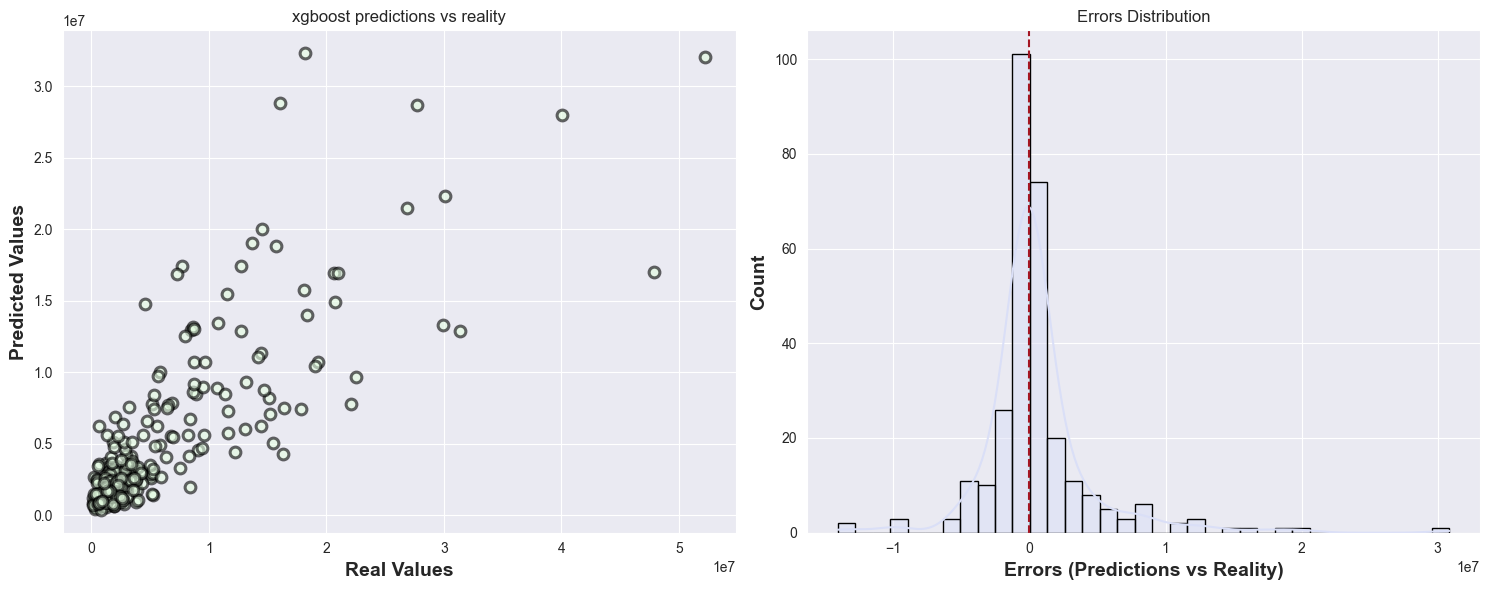

In [45]:
# Trace des résidus.
plot_residuals(y_true=y_test2, y_pred=y_pred_test2, model_name='xgboost')

## RandomForest Model

In [46]:
# Entrainement d'un modèle RandomForestRegressor.
trainer_forest = ModelTrainer(model_type='random_forest')

In [47]:
# Definition du modèle de base.
base_model_forest = trainer_forest.build_pipeline(use_log_target=True)

2026-02-18 22:57:53 | INFO     | energy_sights.modeling.train - Model configuration with a logarithm transformation of the target .
2026-02-18 22:57:53.127 | INFO     | energy_sights.modeling.train:build_pipeline:85 - Model configuration with a logarithm transformation of the target .


In [48]:
y_train.shape

(1168, 1)

In [49]:
# Conversion de y_train au format vectoriel attendu.
y_train_squeezed = y_train.squeeze()

In [50]:
y_train_squeezed.shape

(1168,)

In [51]:
# Optimisation de random_forest via une recherche aleatoire d'hyperparametres.
best_forest_model = tune_model(model=base_model_forest,
                               X_train=X_train,
                               y_train=y_train_squeezed,
                               model_type='random_forest',
                               n_iter=30)

2026-02-18 22:57:53 | INFO     | energy_sights.modeling.tuning - Start of the tuning the: 2026-02-18 22:57:53.770414
2026-02-18 22:57:53.770 | INFO     | energy_sights.modeling.tuning:tune_model:49 - Start of the tuning the: 2026-02-18 22:57:53.770414
Fitting 5 folds for each of 30 candidates, totalling 150 fits
The best parameters finds are: {'regressor__model__n_estimators': 300, 'regressor__model__min_samples_split': 10, 'regressor__model__min_samples_leaf': 5, 'regressor__model__max_features': 0.7, 'regressor__model__max_depth': 12, 'regressor__model__bootstrap': True}
The best Score (RMSE roughly): 1664.72


In [52]:
y_pred_train1 = best_forest_model.predict(X_train)

In [53]:
forest_train_metrics = evaluate_regression(y_true=y_train, y_pred=y_pred_train1, model_name='random_forest')

In [54]:
print_metrics(forest_train_metrics)


 Model performance : random_forest
  RMSE (Root Mean Squared Error) : 4,481,221.59
  MAE  (Mean Absolute Error)     : 1,960,881.89
  MAPE (Error %)           : 40.50%
  R²   (Score explication)  : 0.7498


In [55]:
# Evaluation sur l'ensemble de test.
y_pred_test = best_forest_model.predict(X_test)

In [56]:
forest_test_metrics = evaluate_regression(y_true=y_test, y_pred=y_pred_test, model_name='random_forest')

In [57]:
print_metrics(metrics=forest_test_metrics)


 Model performance : random_forest
  RMSE (Root Mean Squared Error) : 4,594,336.30
  MAE  (Mean Absolute Error)     : 2,180,684.57
  MAPE (Error %)           : 64.32%
  R²   (Score explication)  : 0.6365


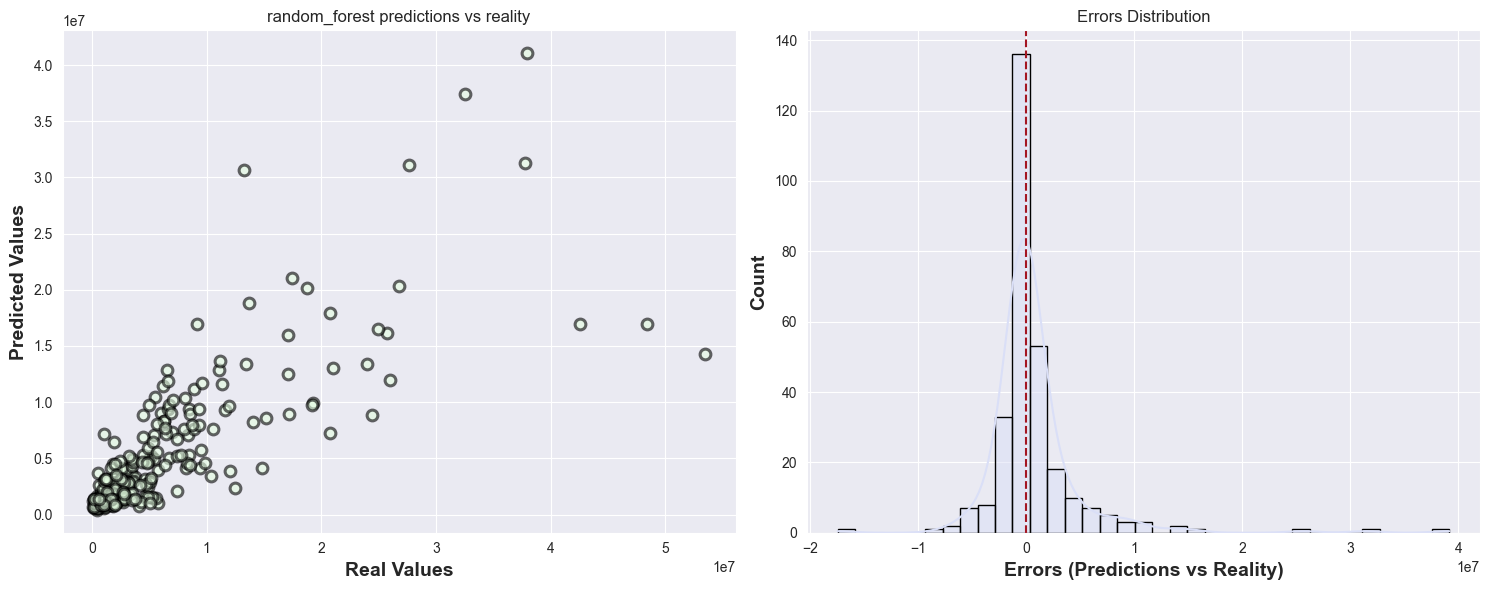

In [58]:
plot_residuals(y_true=y_test,
               y_pred=y_pred_test,
               model_name='random_forest')

In [59]:
# Repetition de la meme procedure avec le modèle random_forest.
best_forest_model2 = tune_model(model=base_model_forest,
                                X_train=X_train2,
                                y_train=y_train2.squeeze(),
                                model_type='random_forest',
                                n_iter=30)

2026-02-18 22:58:39 | INFO     | energy_sights.modeling.tuning - Start of the tuning the: 2026-02-18 22:58:39.645049
2026-02-18 22:58:39.645 | INFO     | energy_sights.modeling.tuning:tune_model:49 - Start of the tuning the: 2026-02-18 22:58:39.645049
Fitting 5 folds for each of 30 candidates, totalling 150 fits
The best parameters finds are: {'regressor__model__n_estimators': 300, 'regressor__model__min_samples_split': 10, 'regressor__model__min_samples_leaf': 5, 'regressor__model__max_features': 0.7, 'regressor__model__max_depth': 12, 'regressor__model__bootstrap': True}
The best Score (RMSE roughly): 1667.29


In [60]:
y_pred_train2 = best_forest_model2.predict(X_train2)

In [61]:
print_metrics(metrics=evaluate_regression(y_true=y_train2,
                                          y_pred=y_pred_train2,
                                          model_name='random_forest'))


 Model performance : random_forest
  RMSE (Root Mean Squared Error) : 4,736,009.73
  MAE  (Mean Absolute Error)     : 2,095,673.71
  MAPE (Error %)           : 43.96%
  R²   (Score explication)  : 0.7254


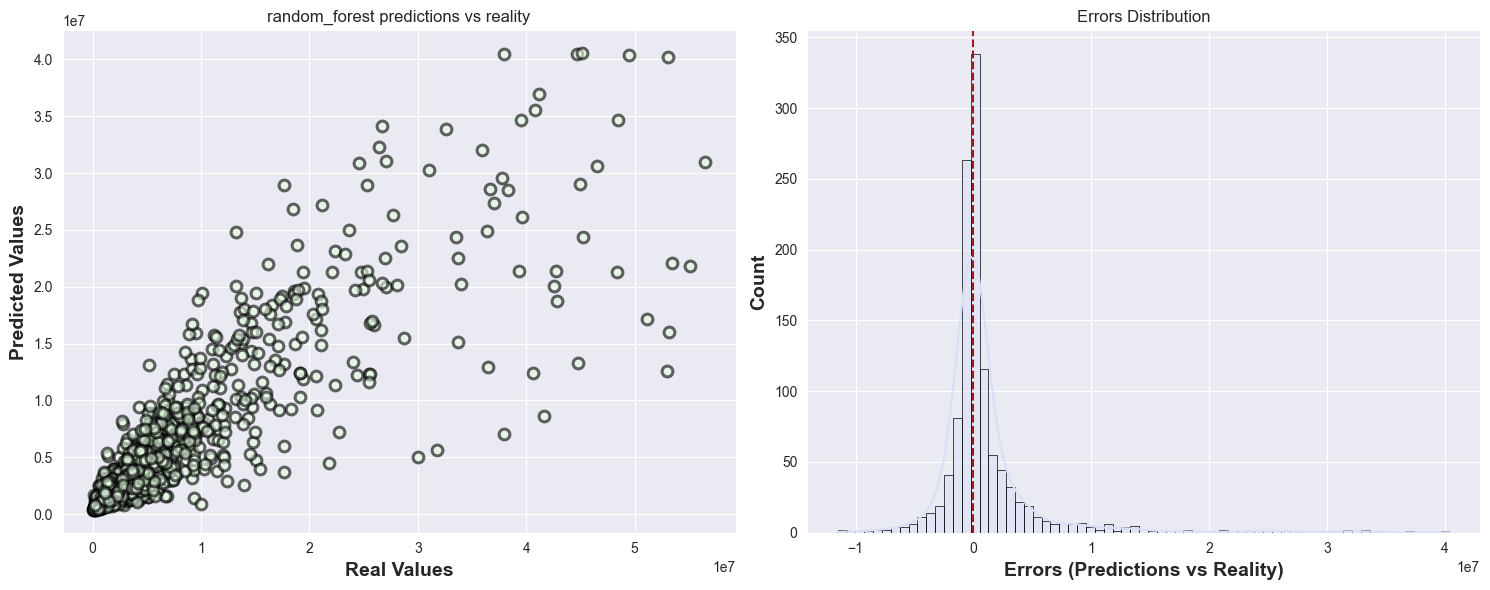

In [62]:
plot_residuals(y_true=y_train2,
               y_pred=y_pred_train2,
               model_name='random_forest')

In [63]:
# Analyse des performances sur les donnees de test.
y_pred_test2 = best_forest_model2.predict(X_test2)

In [64]:
print_metrics(metrics=evaluate_regression(y_true=y_test2,
                                          y_pred=y_pred_test2,
                                          model_name='random_forest'))


 Model performance : random_forest
  RMSE (Root Mean Squared Error) : 4,043,364.51
  MAE  (Mean Absolute Error)     : 2,168,372.09
  MAPE (Error %)           : 65.58%
  R²   (Score explication)  : 0.6851


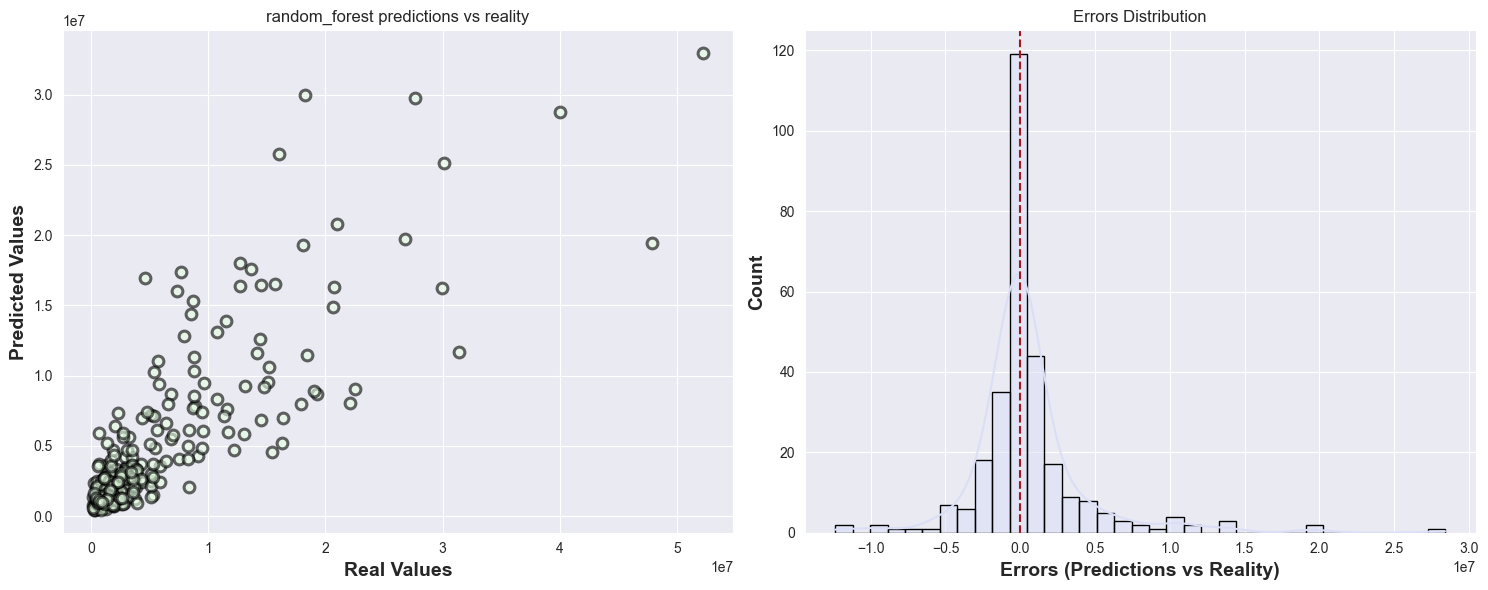

In [65]:
# Visualisation des résidus.
plot_residuals(y_true=y_test2,
               y_pred=y_pred_test2,
               model_name='random_forest')

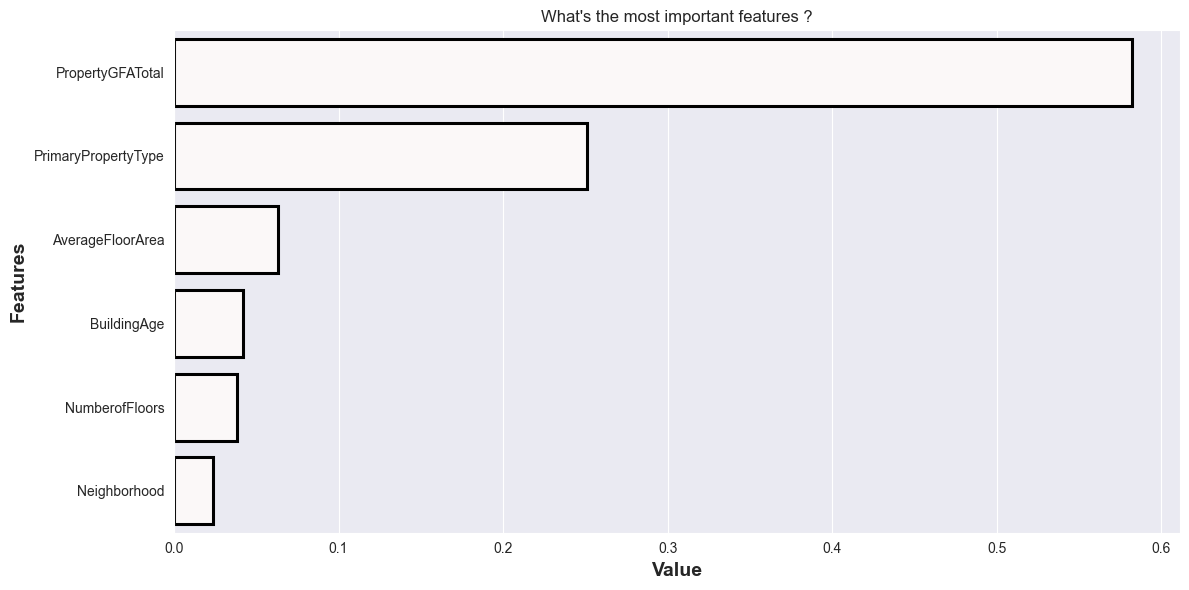

In [66]:
plot_features_importance(model=best_forest_model2,
                         feature_names=X_train2.columns.tolist())

In [67]:
print_feature_importances(model=best_forest_model2, feature_names=X_train2.columns.tolist())

,Features,Values
1,PropertyGFATotal,0.582293
0,PrimaryPropertyType,0.251007
5,AverageFloorArea,0.062892
4,BuildingAge,0.041788
3,NumberofFloors,0.038451
2,Neighborhood,0.023569


In [68]:
# Suppression de NumberofFloors pour analyser l'évolution des performances.
X_train2_nf = X_train2.drop(columns='NumberofFloors')
X_test2_nf = X_test2.drop(columns='NumberofFloors')

In [69]:
# Entrainement d'un nouveau modèle sans NumberofFloors.
best_forest_model3_without_nf = tune_model(model=base_model_forest,
                                           X_train=X_train2_nf,
                                           y_train=y_train2.squeeze(),
                                           model_type='random_forest',
                                           n_iter=30)

2026-02-18 22:59:36 | INFO     | energy_sights.modeling.tuning - Start of the tuning the: 2026-02-18 22:59:36.954026
2026-02-18 22:59:36.954 | INFO     | energy_sights.modeling.tuning:tune_model:49 - Start of the tuning the: 2026-02-18 22:59:36.954026
Fitting 5 folds for each of 30 candidates, totalling 150 fits
The best parameters finds are: {'regressor__model__n_estimators': 300, 'regressor__model__min_samples_split': 10, 'regressor__model__min_samples_leaf': 5, 'regressor__model__max_features': 0.7, 'regressor__model__max_depth': 12, 'regressor__model__bootstrap': True}
The best Score (RMSE roughly): 1673.57


In [70]:
# Evaluation du modèle sans NumberofFloors.
# Résultats sur l'ensemble d'entrainement.
y_pred_train_without_nf = best_forest_model3_without_nf.predict(X_train2_nf)

In [71]:
# Evaluation du modèle sans la variable NumberofFloors sur l'ensemble d'entrainement.
print_metrics(metrics=evaluate_regression(
    y_true=y_train2,
    y_pred=y_pred_train_without_nf,
    model_name='random_forest'
))


 Model performance : random_forest
  RMSE (Root Mean Squared Error) : 4,798,248.26
  MAE  (Mean Absolute Error)     : 2,131,752.60
  MAPE (Error %)           : 44.44%
  R²   (Score explication)  : 0.7182


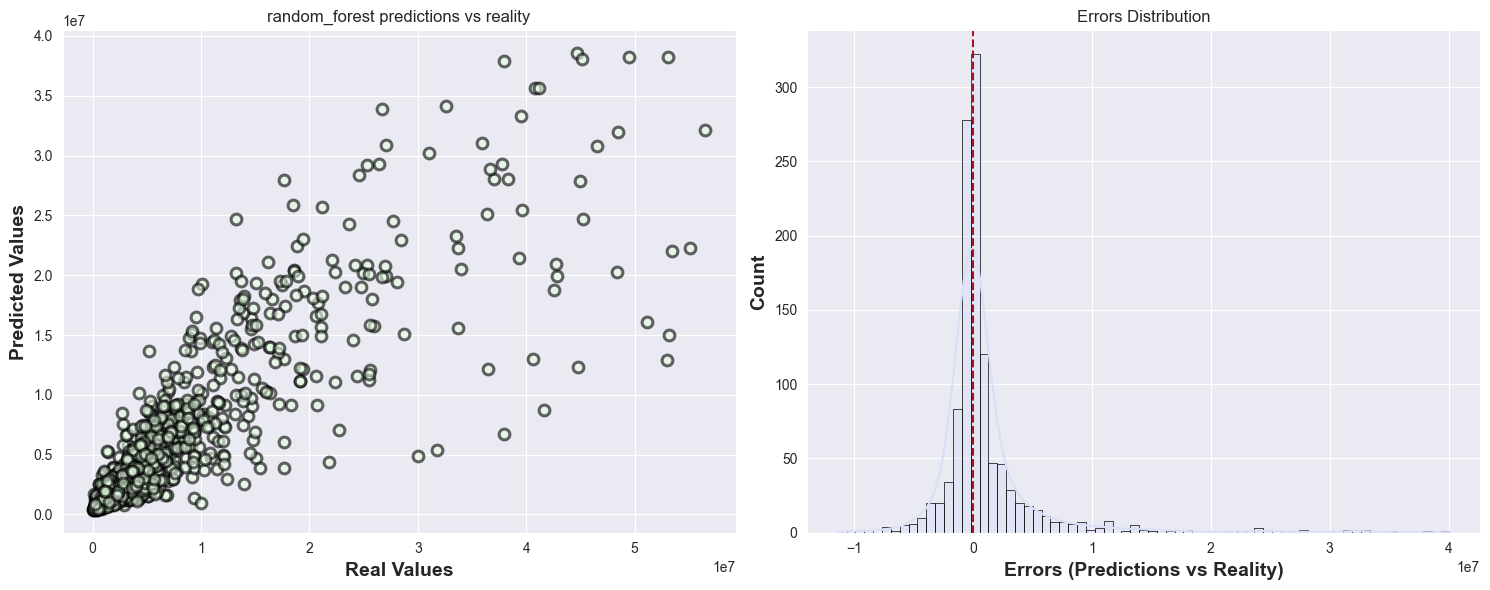

In [72]:
plot_residuals(y_true=y_train2,
               y_pred=y_pred_train_without_nf,
               model_name='random_forest')

In [73]:
y_pred_test_without_nf = best_forest_model3_without_nf.predict(X_test2_nf)

In [74]:
print_metrics(metrics=evaluate_regression(y_true=y_test2,
                                          y_pred=y_pred_test_without_nf,
                                          model_name='random_forest'))


 Model performance : random_forest
  RMSE (Root Mean Squared Error) : 4,040,175.03
  MAE  (Mean Absolute Error)     : 2,170,331.06
  MAPE (Error %)           : 65.86%
  R²   (Score explication)  : 0.6856


In [76]:
print_feature_importances(model=best_forest_model3_without_nf, feature_names=X_train2_nf.columns.tolist())

,Features,Values
1,PropertyGFATotal,0.579575
0,PrimaryPropertyType,0.268174
4,AverageFloorArea,0.073461
3,BuildingAge,0.046805
2,Neighborhood,0.031984


In [75]:
# # Sauvegarde du modèle pour utilisation en production.
# trainer_forest.model = best_forest_model3_without_nf
# trainer_forest.save_model(model_name='energy_model.pkl')